SVHN

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
transform_svhn = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

svhn_train = datasets.SVHN(root='./data', split='train', download=True, transform=transform_svhn)
svhn_test  = datasets.SVHN(root='./data', split='test', download=True, transform=transform_svhn)

subset_size = 10000
svhn_train = torch.utils.data.Subset(svhn_train, range(subset_size))
svhn_test  = torch.utils.data.Subset(svhn_test, range(2000))

train_loader = torch.utils.data.DataLoader(svhn_train, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(svhn_test, batch_size=64, shuffle=False)

100%|██████████| 182M/182M [00:06<00:00, 27.4MB/s]
100%|██████████| 64.3M/64.3M [00:08<00:00, 7.80MB/s]


In [9]:
import torch.nn as nn
import torchvision.models as models

#RESNET
svhn_model = models.resnet18(pretrained=False)
svhn_model.fc = nn.Linear(svhn_model.fc.in_features, 10)
svhn_model = svhn_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [11]:
#Train model
def train(model, loader, optimizer, criterion, epochs=3):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            labels = labels % 10

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(svhn_model.parameters(), lr=0.001)

train(svhn_model, train_loader, optimizer, criterion, epochs=5)

Epoch 1, Loss: 0.3932
Epoch 2, Loss: 0.2811
Epoch 3, Loss: 0.2116
Epoch 4, Loss: 0.1561
Epoch 5, Loss: 0.1236


In [15]:
def test_clean(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            labels = labels % 10

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

In [17]:
print("\nCLEAN TEST")

svhn_clean = test_clean(svhn_model, test_loader)
print(f"Clean Accuracy: {svhn_clean:.2f}%")


CLEAN TEST
Clean Accuracy: 83.75%


In [1]:
#FGSM function
def fgsm_attack(model, images, labels, epsilon):
    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    return torch.clamp(adv_images, -1, 1)

In [37]:
#PGD
def pgd_attack(model, images, labels, epsilon, iters=7):
    ori_images = images.clone()

    alpha = epsilon / 4

    for _ in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        images = images + alpha * images.grad.sign()
        eta = torch.clamp(images - ori_images, -epsilon, epsilon)
        images = torch.clamp(ori_images + eta, -1, 1).detach()

    return images

In [38]:
#Test FGSM
def test_model(model, loader, epsilon, attack="fgsm"):
    model.eval()
    correct, total = 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        labels = labels % 10

        if attack == "fgsm":
            adv_images = fgsm_attack(model, images, labels, epsilon)
        else:
            adv_images = pgd_attack(model, images, labels, epsilon)

        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return 100 * correct / total

In [39]:
#FGSM test
print("\nFGSM ATTACK RESULTS")

epsilons = [0.05, 0.1, 0.15]

svhn_fgsm_before = []

for eps in epsilons:
    acc = test_model(svhn_model, test_loader, eps, "fgsm")
    svhn_fgsm_before.append(acc)
    print(f"Epsilon {eps}: FGSM Accuracy = {acc:.2f}%")


FGSM ATTACK RESULTS
Epsilon 0.05: FGSM Accuracy = 10.80%
Epsilon 0.1: FGSM Accuracy = 1.55%
Epsilon 0.15: FGSM Accuracy = 0.55%


In [40]:
#PGD
print("\nPGD ATTACK RESULTS")

svhn_pgd_before = []

for eps in epsilons:
    acc = test_model(svhn_model, test_loader, eps, "pgd")
    svhn_pgd_before.append(acc)
    print(f"Epsilon {eps}: PGD Accuracy = {acc:.2f}%")


PGD ATTACK RESULTS
Epsilon 0.05: PGD Accuracy = 3.50%
Epsilon 0.1: PGD Accuracy = 0.10%
Epsilon 0.15: PGD Accuracy = 0.00%


In [41]:
#Autoencoder
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [42]:
#Train Autoencoder
def train_autoencoder(ae, classifier, loader, epochs=2):
    ae.train()
    optimizer = torch.optim.Adam(ae.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            labels = labels % 10

            adv_images = fgsm_attack(classifier, images, labels, 0.1)

            outputs = ae(adv_images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"AE Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

In [43]:
#Apply Defense
print("\nTRAINING AUTOENCODER")

autoencoder_svhn = Autoencoder().to(device)
train_autoencoder(autoencoder_svhn, svhn_model, train_loader)


TRAINING AUTOENCODER
AE Epoch 1, Loss: 0.0514
AE Epoch 2, Loss: 0.0139


In [44]:
#After Defense
def test_with_ae(model, ae, loader, epsilon):
    model.eval()
    ae.eval()

    correct, total = 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        labels = labels % 10

        adv_images = fgsm_attack(model, images, labels, epsilon)
        recon = ae(adv_images)

        outputs = model(recon)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return 100 * correct / total

In [45]:
print("\nAFTER DEFENSE (FGSM)")

svhn_fgsm_after = []

for eps in epsilons:
    acc = test_with_ae(svhn_model, autoencoder_svhn, test_loader, eps)
    svhn_fgsm_after.append(acc)
    print(f"Epsilon {eps}: After Defense Accuracy = {acc:.2f}%")


AFTER DEFENSE (FGSM)
Epsilon 0.05: After Defense Accuracy = 22.80%
Epsilon 0.1: After Defense Accuracy = 7.00%
Epsilon 0.15: After Defense Accuracy = 2.25%


In [46]:
#Final comparision
print("\nFINAL COMPARISON TABLE")

print(f"\nClean Accuracy: {svhn_clean:.2f}%")

for i, eps in enumerate(epsilons):
    print(f"\nEpsilon {eps}:")
    print(f"FGSM Before: {svhn_fgsm_before[i]:.2f}%")
    print(f"PGD Before: {svhn_pgd_before[i]:.2f}%")
    print(f"After Defense: {svhn_fgsm_after[i]:.2f}%")


FINAL COMPARISON TABLE

Clean Accuracy: 83.75%

Epsilon 0.05:
FGSM Before: 10.80%
PGD Before: 3.50%
After Defense: 22.80%

Epsilon 0.1:
FGSM Before: 1.55%
PGD Before: 0.10%
After Defense: 7.00%

Epsilon 0.15:
FGSM Before: 0.55%
PGD Before: 0.00%
After Defense: 2.25%


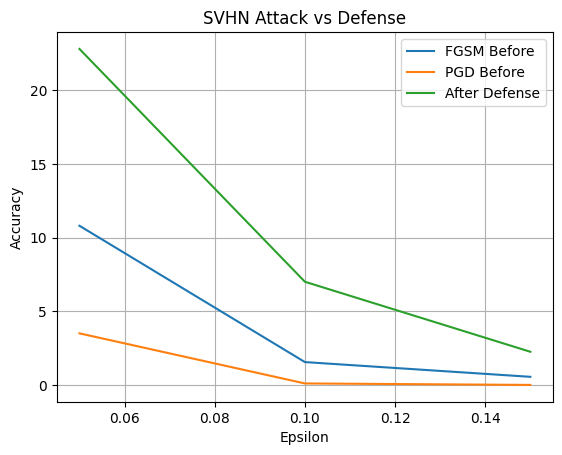

In [47]:
#Graph
plt.plot(epsilons, svhn_fgsm_before, label="FGSM Before")
plt.plot(epsilons, svhn_pgd_before, label="PGD Before")
plt.plot(epsilons, svhn_fgsm_after, label="After Defense")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("SVHN Attack vs Defense")
plt.legend()
plt.grid()
plt.show()

| Dataset | Model    | Clean | FGSM (0.05) | FGSM (0.1) | FGSM (0.15) | PGD (0.05) | PGD (0.1) | PGD (0.15) | Defense (0.05) | Defense (0.1) | Defense (0.15) |
| ------- | -------- | ----- | ----------- | ---------- | ----------- | ---------- | --------- | ---------- | -------------- | ------------- | -------------- |
| MNIST   | VGG16    | 90.89 | 73.96       | 56.07      | 41.98       | 39.61      | 3.92      | 0.33       | 64.43          | 54.13         | 46.58          |
| Fashion | VGG16    | 77.73 | 51.98       | 36.88      | 27.79       | 36.33      | 9.47      | 2.50       | 56.02          | 50.24         | 46.74          |
| SVHN    | ResNet18 | 83.75 | 10.80       | 1.55       | 0.55        | 3.50       | 0.10      | 0.00       | 22.80          | 7.00          | 2.25           |
